In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirzayasirabdullah07/software-defect-prediction-dataset/software_defect_prediction_dataset.csv


In [2]:
import pandas as pd

# Load the dataset
file_path = "/kaggle/input/datasets/mirzayasirabdullah07/software-defect-prediction-dataset/software_defect_prediction_dataset.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   lines_of_code               60000 non-null  int64  
 1   cyclomatic_complexity       60000 non-null  int64  
 2   num_functions               60000 non-null  int64  
 3   num_classes                 60000 non-null  int64  
 4   comment_density             60000 non-null  float64
 5   code_churn                  60000 non-null  int64  
 6   developer_experience_years  60000 non-null  int64  
 7   num_developers              60000 non-null  int64  
 8   commit_frequency            60000 non-null  int64  
 9   bug_fix_commits             60000 non-null  int64  
 10  past_defects                60000 non-null  int64  
 11  test_coverage               60000 non-null  float64
 12  duplication_percentage      60000 non-null  float64
 13  avg_function_length         600

In [4]:
df.describe()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000,60000.000000,60000.000000
mean,2530.351467,25.085650,99.900683,49.371517,0.300259,500.247800,9.465667,7.492883,150.296117,99.262667,...,102.109167,4.506767,49.991167,25.099967,0.499512,9.467117,248.720767,24.44745,14.473250,0.970383
std,1428.229382,14.112331,57.367154,28.827881,0.173254,288.724453,5.768672,4.032777,86.375771,57.774507,...,56.279245,2.866878,28.721025,14.139460,0.289559,5.746556,144.011768,14.46083,8.663821,0.169529
min,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,5.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1299.000000,13.000000,50.000000,24.000000,0.150000,251.000000,4.000000,4.000000,76.000000,49.000000,...,53.000000,2.000000,25.000000,13.000000,0.250000,4.000000,124.000000,12.00000,7.000000,1.000000
50%,2534.000000,25.000000,99.000000,49.000000,0.300000,501.000000,9.000000,7.000000,151.000000,99.000000,...,102.000000,5.000000,50.000000,25.000000,0.500000,9.000000,249.000000,24.00000,14.000000,1.000000
75%,3763.000000,37.000000,149.000000,74.000000,0.450000,750.000000,14.000000,11.000000,225.000000,149.000000,...,151.000000,7.000000,75.000000,37.000000,0.750000,14.000000,373.000000,37.00000,22.000000,1.000000
max,4999.000000,49.000000,199.000000,99.000000,0.600000,999.000000,19.000000,14.000000,299.000000,199.000000,...,199.000000,9.000000,99.000000,49.000000,1.000000,19.000000,499.000000,49.00000,29.000000,1.000000


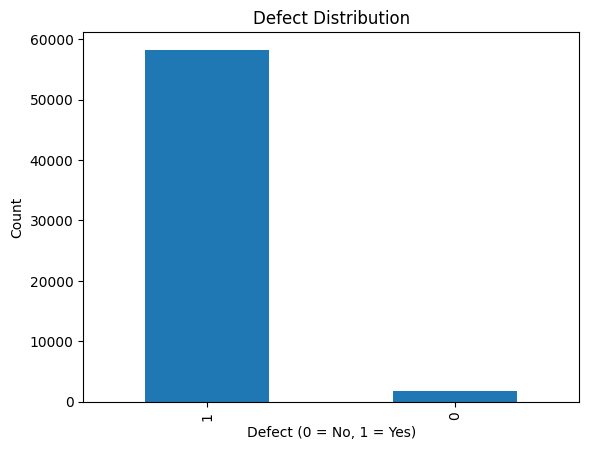

In [5]:
import matplotlib.pyplot as plt

df['defect'].value_counts().plot(kind='bar')
plt.title("Defect Distribution")
plt.xlabel("Defect (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

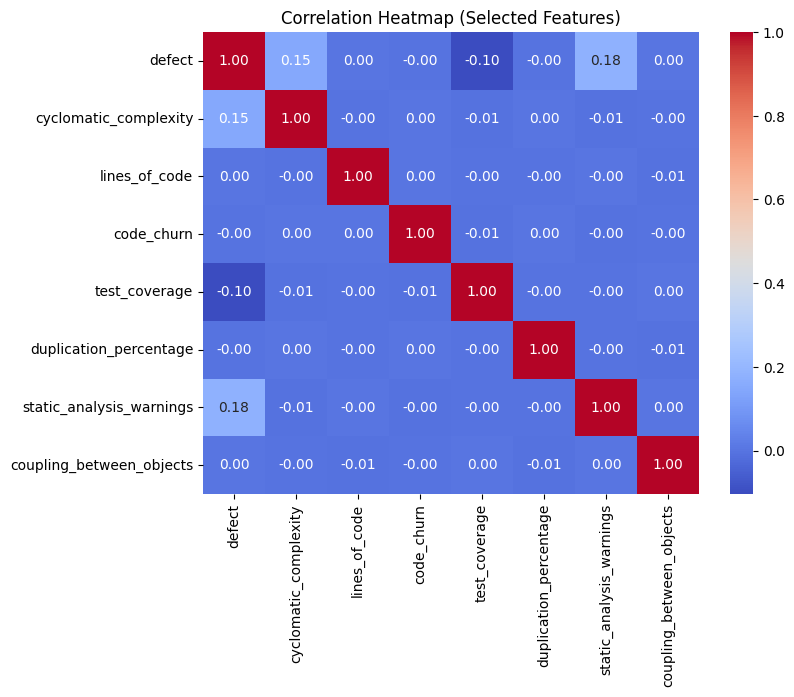

In [25]:
cols = [
    'defect',
    'cyclomatic_complexity',
    'lines_of_code',
    'code_churn',
    'test_coverage',
    'duplication_percentage',
    'static_analysis_warnings',
    'coupling_between_objects'
]

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap (Selected Features)")
plt.show()

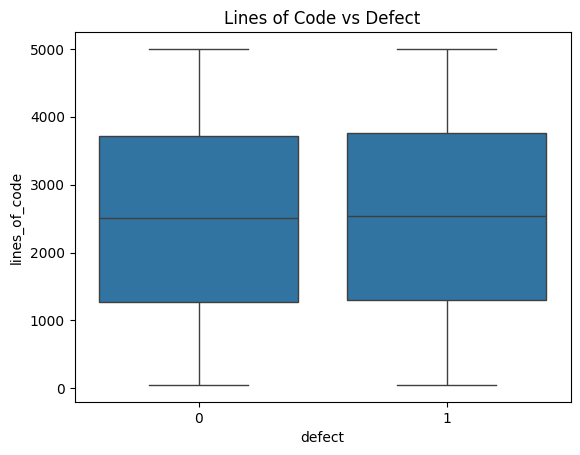

In [7]:
sns.boxplot(x='defect', y='lines_of_code', data=df)
plt.title("Lines of Code vs Defect")
plt.show()

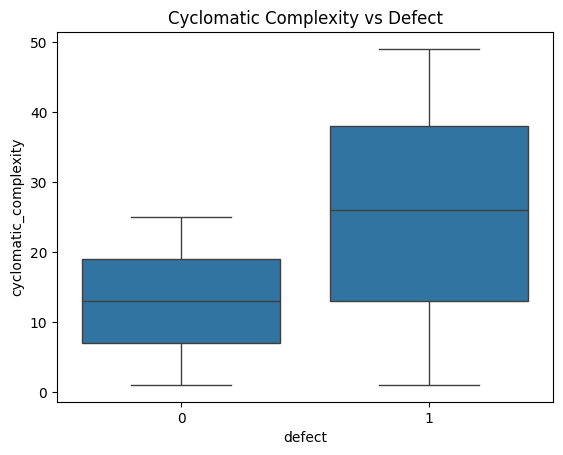

In [8]:
sns.boxplot(x='defect', y='cyclomatic_complexity', data=df)
plt.title("Cyclomatic Complexity vs Defect")
plt.show()

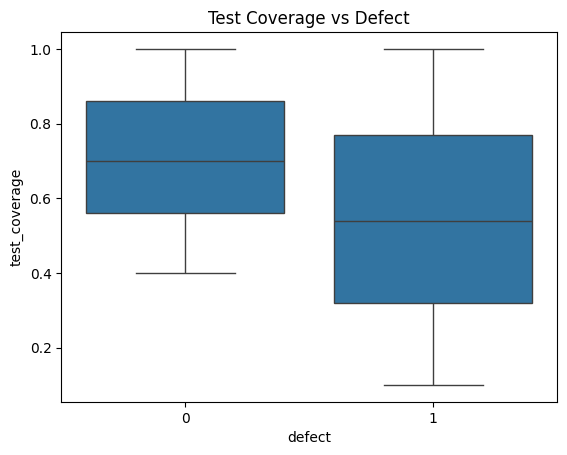

In [9]:
sns.boxplot(x='defect', y='test_coverage', data=df)
plt.title("Test Coverage vs Defect")
plt.show()

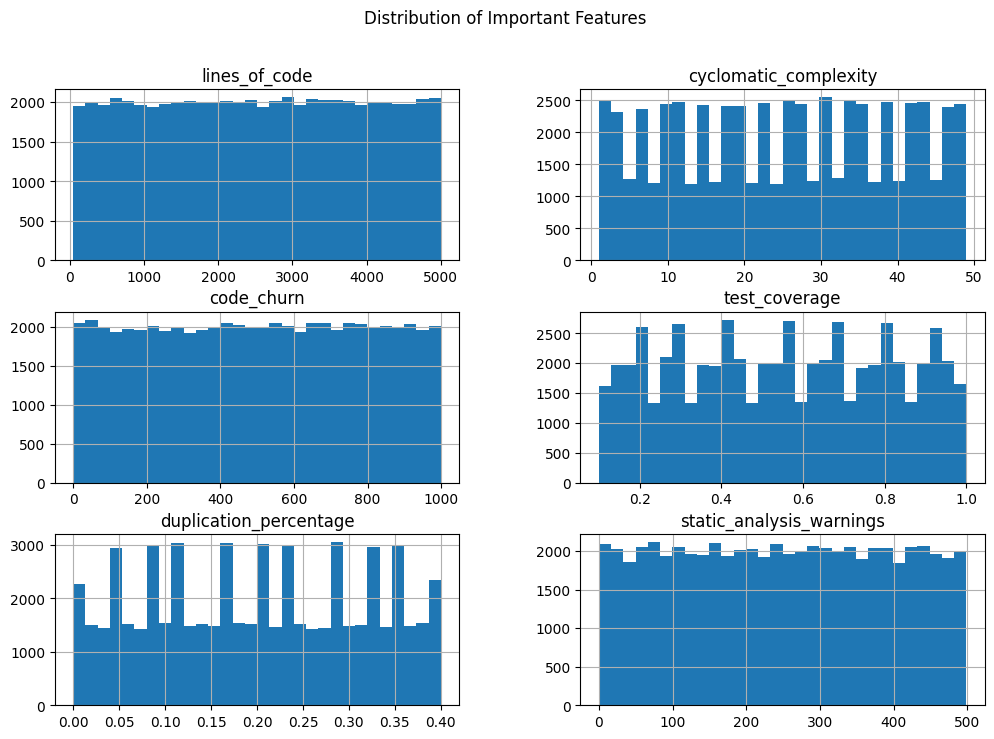

In [24]:
cols = [
    'lines_of_code',
    'cyclomatic_complexity',
    'code_churn',
    'test_coverage',
    'duplication_percentage',
    'static_analysis_warnings'
]

df[cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Important Features")
plt.show()

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
#df = pd.read_csv("/kaggle/input/datasets/mirzayasirabdullah07/software-defect-prediction-dataset/software_defect_prediction_dataset.csv")

# Features & target
X = df.drop('defect', axis=1)
y = df['defect']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (important for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"{name} Confusion Matrix:\n", cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()


Random Forest Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       355
           1     1.0000    1.0000    1.0000     11645

    accuracy                         1.0000     12000
   macro avg     1.0000    1.0000    1.0000     12000
weighted avg     1.0000    1.0000    1.0000     12000

Random Forest Confusion Matrix:
 [[  355     0]
 [    0 11645]]


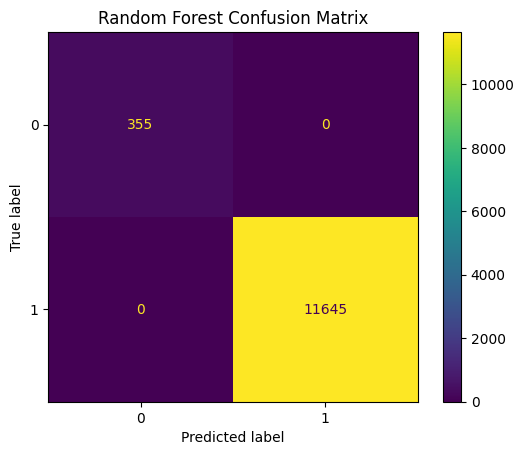


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       355
           1     1.0000    1.0000    1.0000     11645

    accuracy                         1.0000     12000
   macro avg     1.0000    1.0000    1.0000     12000
weighted avg     1.0000    1.0000    1.0000     12000

Gradient Boosting Confusion Matrix:
 [[  355     0]
 [    0 11645]]


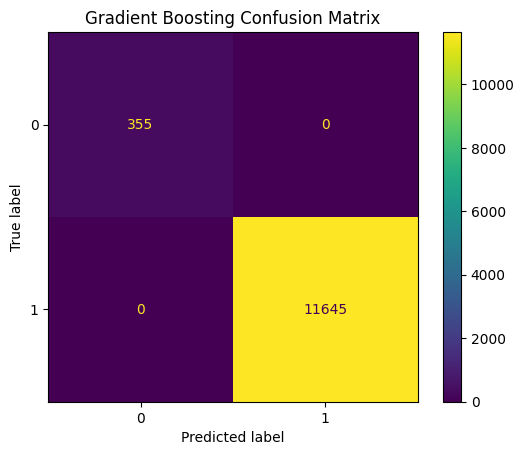

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:47:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classification Report:
              precision    recall  f1-score   support

           0     0.9944    1.0000    0.9972       355
           1     1.0000    0.9998    0.9999     11645

    accuracy                         0.9998     12000
   macro avg     0.9972    0.9999    0.9986     12000
weighted avg     0.9998    0.9998    0.9998     12000

XGBoost Confusion Matrix:
 [[  355     0]
 [    2 11643]]


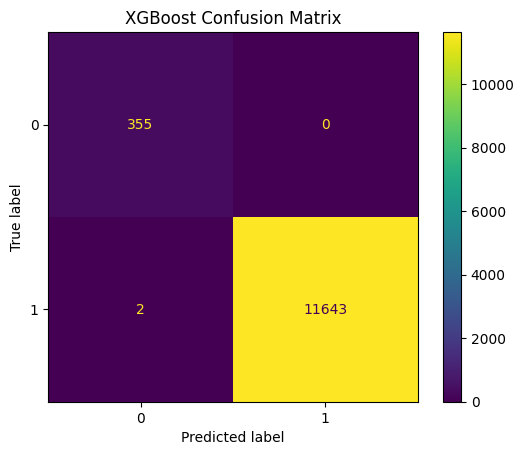

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-18 11:47:43.830562: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9580 - loss: 0.1244 - val_accuracy: 0.9831 - val_loss: 0.0405
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9828 - loss: 0.0413 - val_accuracy: 0.9868 - val_loss: 0.0321
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9883 - loss: 0.0283 - val_accuracy: 0.9895 - val_loss: 0.0259
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9905 - loss: 0.0225 - val_accuracy: 0.9889 - val_loss: 0.0251
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9923 - loss: 0.0196 - val_accuracy: 0.9908 - val_loss: 0.0233
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9927 - loss: 0.0164 - val_accuracy: 0.9914 - val_loss: 0.0207
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9943 - loss: 0.0146 - val_accuracy: 0.9925 - val_loss: 0.0195
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9956 - loss: 0.0118 - val_accurac

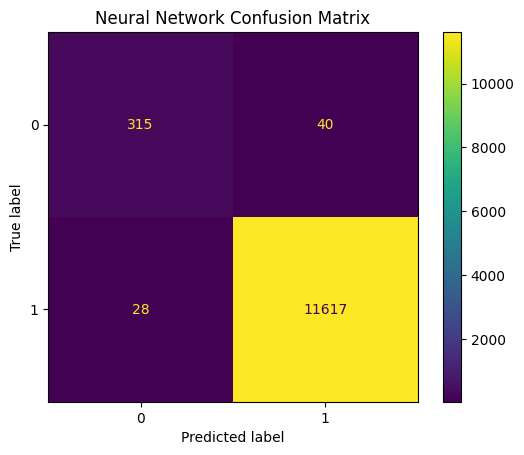

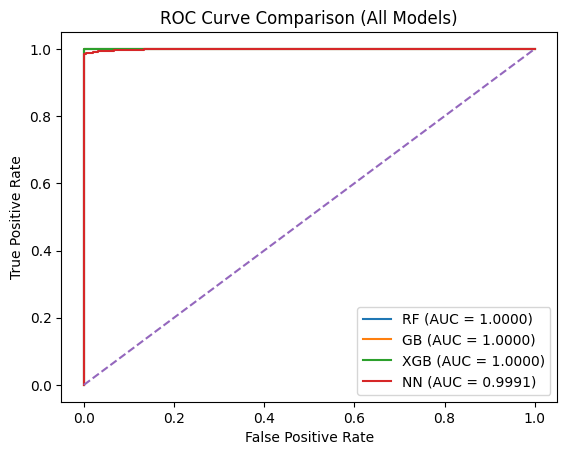

In [23]:
# ---------------------------
# Train Models
# ---------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, y_pred_rf)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
evaluate_model("XGBoost", y_test, y_pred_xgb)

# ---------------------------
# 6. Deep Neural Network
# ---------------------------
nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

y_prob_nn = nn.predict(X_test_scaled).ravel()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

evaluate_model("Neural Network", y_test, y_pred_nn)

# ---------------------------
# 7. ROC Curve (ALL MODELS)
# ---------------------------
plt.figure()

# RF
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})")

# GB
y_prob_gb = gb.predict_proba(X_test_scaled)[:,1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label=f"GB (AUC = {roc_auc_score(y_test, y_prob_gb):.4f})")

# XGB
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC = {roc_auc_score(y_test, y_prob_xgb):.4f})")

# NN
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
plt.plot(fpr_nn, tpr_nn, label=f"NN (AUC = {roc_auc_score(y_test, y_prob_nn):.4f})")

# Baseline
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.show()

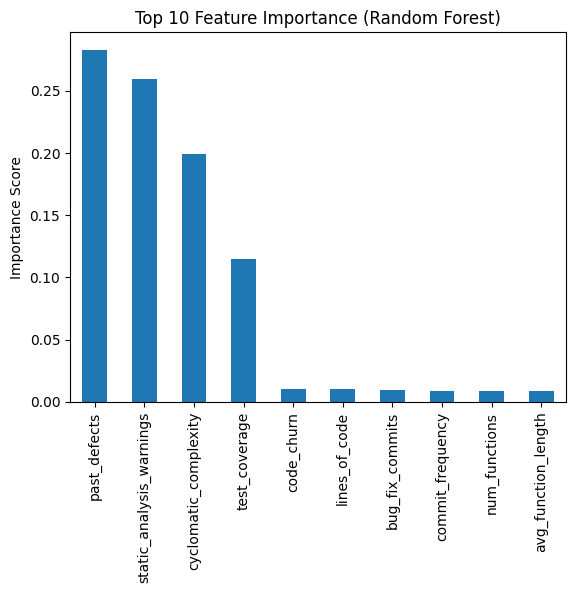

In [26]:
# Get feature importance
importances = rf.feature_importances_

# Create DataFrame
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Plot Top 10
plt.figure()
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()